# Tutorial 3: Running Quantization-Aware Training (QAT) on Bert

In this tutorial, we'll build on top of Tutorial 2 by taking the Bert model fine tuned for sequence classification and running Mase's quantization pass. First, we'll run simple Post-Training Quantization (PTQ) and see how much accuracy drops. Then, we'll run some further training iterations of the quantized model (i.e. QAT) and see whether the accuracy of the trained quantized model approaches the accuracy of the original (full-precision) model.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [2]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

/opt/anaconda3/envs/mase/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/mase/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_ca

tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on LoRA Finetuning, run the following cell to import the fine tuned checkpoint.

In [3]:
from chop import MaseGraph

mg = MaseGraph.from_checkpoint("../lab_0/tutorial_2/tutorial_2_lora") #loading from my current dir

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


## Post-Training Quantization (PTQ)

Here, we simply quantize the model and evaluate the effect in its accuracy. First, let's evaluate the model accuracy before quantization (if you're coming from Tutorial 2, this should be the same as the post-LoRA evaluation accuracy). As seen in Tutorial 2, we can use the `get_tokenized_dataset` and `get_trainer` utilities to generate a HuggingFace `Trainer` instance for training and evaluation.

In [4]:


from chop.tools import get_tokenized_dataset, get_trainer


In [5]:

#Train had been already done in lab_0. so i interrupted this
dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Map: 100%|██████████| 25000/25000 [00:04<00:00, 5435.61 examples/s]
/Users/alihaidar/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.83448


To run the quantization pass, we pass a quantization configuration dictionary as argument. This defines the quantization mode, numerical format and precision for each operator in the graph. We'll run the quantization in "by type" mode, meaning nodes are quantized according to their `mase_op`. Other modes include by name and by regex name. We'll quantize all activations, weights and biases in the model to fixed-point with the same precision. This may be sub-optimal, but works as an example. In future tutorials, we'll see how to run the `search` flow in `Mase` to find optimal quantization configurations to minimize accuracy loss.

In [6]:
import chop.passes as passes

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

mg, _ = passes.quantize_transform_pass(
    mg,
    pass_args=quantization_config,
)

Let's evaluate the immediate effect of quantization on the model accuracy.

In [7]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/Users/alihaidar/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.81932


We can save the current checkpoint for future reference (optional).

In [8]:
mg.export("tutorial_3_ptq")

INFO     Exporting MaseGraph to tutorial_3_ptq.pt, tutorial_3_ptq.mz
INFO     Exporting GraphModule to tutorial_3_ptq.pt


INFO     Saving full model format
INFO     Exporting MaseMetadata to tutorial_3_ptq.mz


## Quantization-Aware Training (QAT)

You should have seen in the last section that quantization can lead to a significant drop in accuracy. Next, we'll run QAT to evaluate whether this performance gap can be reduced. To run QAT in Mase, all you need to do is include the model back in your training loop after running the quantization pass.

In [9]:
# Evaluate accuracy
trainer.train()
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Step,Training Loss
500,0.413400
1000,0.398200
1500,0.400100
2000,0.388400
2500,0.387800
3000,0.392600


Evaluation accuracy: 0.83936


We can see the accuracy of the quantized model can match (or sometimes exceed) the full precision model, with a much lower memory requirement to store the weights. Finally, save the final checkpoint for future tutorials.

In [10]:
mg.export("tutorial_3_qat")

INFO     Exporting MaseGraph to tutorial_3_qat.pt, tutorial_3_qat.mz
INFO     Exporting GraphModule to tutorial_3_qat.pt
INFO     Saving full model format
INFO     Exporting MaseMetadata to tutorial_3_qat.mz


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


Starting fixed point width exploration...

Testing width: 4 bits

[PTQ] Running Post-Training Quantization...


/Users/alihaidar/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[PTQ] Accuracy: 0.50000

[QAT] Running Quantization-Aware Training...


/Users/alihaidar/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

/Users/alihaidar/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[PTQ] Accuracy: 0.83448

[QAT] Running Quantization-Aware Training...


/Users/alihaidar/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.398800
1000,0.387200
1500,0.397000
2000,0.377200
2500,0.385800
3000,0.384400


[QAT] Accuracy: 0.84196
[QAT] Improvement: +0.00748


Exploration complete!



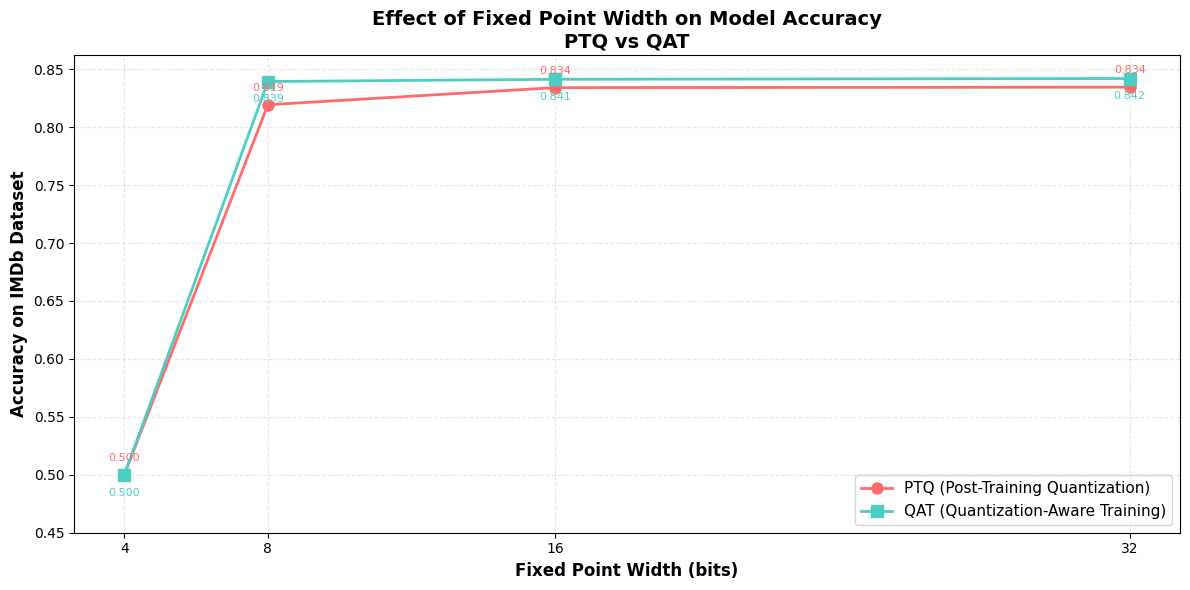


Summary Table:
Width      PTQ Acc      QAT Acc      Improvement 
--------------------------------------------------
4          0.50000      0.50000      0.00000     
8          0.81932      0.83936      0.02004     
16         0.83408      0.84128      0.00720     
32         0.83448      0.84196      0.00748     


In [12]:
# Exploration of different fixed point widths
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

# Define the range of fixed point widths to test
widths_to_test = [4, 8, 16, 32]

# Storage for results
ptq_accuracies = []
qat_accuracies = []

# Load the LORA fine-tuned model from Tutorial 2 (the correct checkpoint!)
from chop import MaseGraph
from pathlib import Path

original_mg = MaseGraph.from_checkpoint("../lab_0/tutorial_2/tutorial_2_lora")

print("Starting fixed point width exploration...\n")

for width in widths_to_test:
    print(f"{'='*60}")
    print(f"Testing width: {width} bits")
    print(f"{'='*60}")
    
    # Determine fractional width (use half of total width)
    frac_width = width // 2
    
    # ========== PTQ: Post-Training Quantization ==========
    print(f"\n[PTQ] Running Post-Training Quantization...")
    
    # Create a fresh copy of the model for PTQ
    mg_ptq = deepcopy(original_mg)
    
    # Create quantization configuration for PTQ
    quantization_config_ptq = {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": width,
                "data_in_frac_width": frac_width,
                # weight
                "weight_width": width,
                "weight_frac_width": frac_width,
                # bias
                "bias_width": width,
                "bias_frac_width": frac_width,
            }
        },
    }
    
    # Apply quantization
    mg_ptq, _ = passes.quantize_transform_pass(
        mg_ptq,
        pass_args=quantization_config_ptq,
    )
    
    # Evaluate PTQ (no training)
    trainer_ptq = get_trainer(
        model=mg_ptq.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
    )
    eval_results_ptq = trainer_ptq.evaluate()
    ptq_acc = eval_results_ptq['eval_accuracy']
    ptq_accuracies.append(ptq_acc)
    print(f"[PTQ] Accuracy: {ptq_acc:.5f}")
    
    # ========== QAT: Quantization-Aware Training ==========
    print(f"\n[QAT] Running Quantization-Aware Training...")
    
    # Create a fresh copy of the model for QAT
    mg_qat = deepcopy(original_mg)
    
    # Create quantization configuration for QAT
    quantization_config_qat = {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": width,
                "data_in_frac_width": frac_width,
                # weight
                "weight_width": width,
                "weight_frac_width": frac_width,
                # bias
                "bias_width": width,
                "bias_frac_width": frac_width,
            }
        },
    }
    
    # Apply quantization
    mg_qat, _ = passes.quantize_transform_pass(
        mg_qat,
        pass_args=quantization_config_qat,
    )
    
    # Train the quantized model
    trainer_qat = get_trainer(
        model=mg_qat.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
    )
    trainer_qat.train()
    
    # Evaluate QAT (after training)
    eval_results_qat = trainer_qat.evaluate()
    qat_acc = eval_results_qat['eval_accuracy']
    qat_accuracies.append(qat_acc)
    print(f"[QAT] Accuracy: {qat_acc:.5f}")
    print(f"[QAT] Improvement: +{(qat_acc - ptq_acc):.5f}\n")

print(f"\n{'='*60}")
print("Exploration complete!")
print(f"{'='*60}\n")

# ========== Plot Results ==========
plt.figure(figsize=(12, 6))

# Plot PTQ and QAT curves
plt.plot(widths_to_test, ptq_accuracies, marker='o', linewidth=2, 
         markersize=8, label='PTQ (Post-Training Quantization)', color='#FF6B6B')
plt.plot(widths_to_test, qat_accuracies, marker='s', linewidth=2, 
         markersize=8, label='QAT (Quantization-Aware Training)', color='#4ECDC4')

# Formatting
plt.xlabel('Fixed Point Width (bits)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy on IMDb Dataset', fontsize=12, fontweight='bold')
plt.title('Effect of Fixed Point Width on Model Accuracy\nPTQ vs QAT', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(widths_to_test)
plt.ylim([min(min(ptq_accuracies), min(qat_accuracies)) - 0.05, 
          max(max(ptq_accuracies), max(qat_accuracies)) + 0.02])

# Add value annotations
for i, (w, ptq, qat) in enumerate(zip(widths_to_test, ptq_accuracies, qat_accuracies)):
    plt.annotate(f'{ptq:.3f}', (w, ptq), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=8, color='#FF6B6B')
    plt.annotate(f'{qat:.3f}', (w, qat), textcoords="offset points", 
                xytext=(0,-15), ha='center', fontsize=8, color='#4ECDC4')

plt.tight_layout()
plt.savefig('ptq_vs_qat_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary table
print("\nSummary Table:")
print(f"{'Width':<10} {'PTQ Acc':<12} {'QAT Acc':<12} {'Improvement':<12}")
print(f"{'-'*50}")
for w, ptq, qat in zip(widths_to_test, ptq_accuracies, qat_accuracies):
    print(f"{w:<10} {ptq:<12.5f} {qat:<12.5f} {qat-ptq:<12.5f}")